In [2]:
#Problemm  statement
# use the relevent machine learning model to predict whether a person is diabetic or non-diabetic


In [1]:
#import the basic libraries
import numpy as np
import pandas as pd
import seaborn as sns
import warnings 
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt

In [2]:
#load the data
data=pd.read_csv("diabetes.csv")

In [3]:
data

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [6]:
#basic checks
#print the first 5 rows
data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [7]:
data.tail()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1
767,1,93,70,31,0,30.4,0.315,23,0


In [8]:
data.columns


Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [7]:
data.dtypes

Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [9]:
#stastical analysis
data.describe().T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


In [10]:
#find the unique values in the outcome
data.Outcome.unique()

array([1, 0])

In [11]:
#find the count of diabetes and non-diabetes
data.Outcome.value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

In [12]:
#data is corrupted becuse Glucose,BP,skinthickness and insulin has zero as its value tht means person is dead

In [13]:
#check for missing values
data.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [14]:
#Exploratory Data Analysis(EDA)
#univariant:
# * hist plot is used to check distribution of data
# *  count plot is used to check whther the data is balanced r not

<Axes: xlabel='Outcome', ylabel='count'>

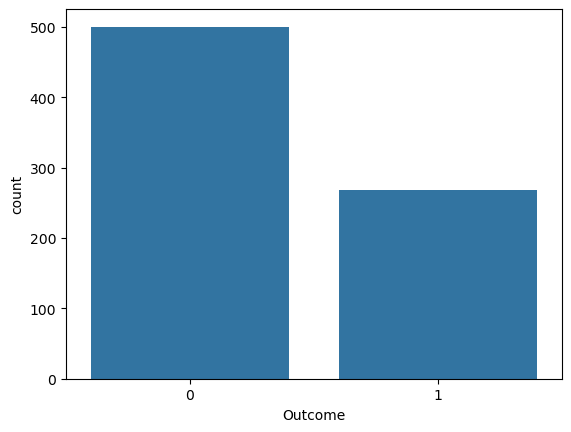

In [15]:
#check whether data is balance dor not
#data balanced:Equal number of records releated to diabetic or non diabetic
sns.countplot(x=data.Outcome)

In [16]:
#insights:
#clearly data is imbalanced since we hv more records releated to non-diabetic and less records releated to diabetic


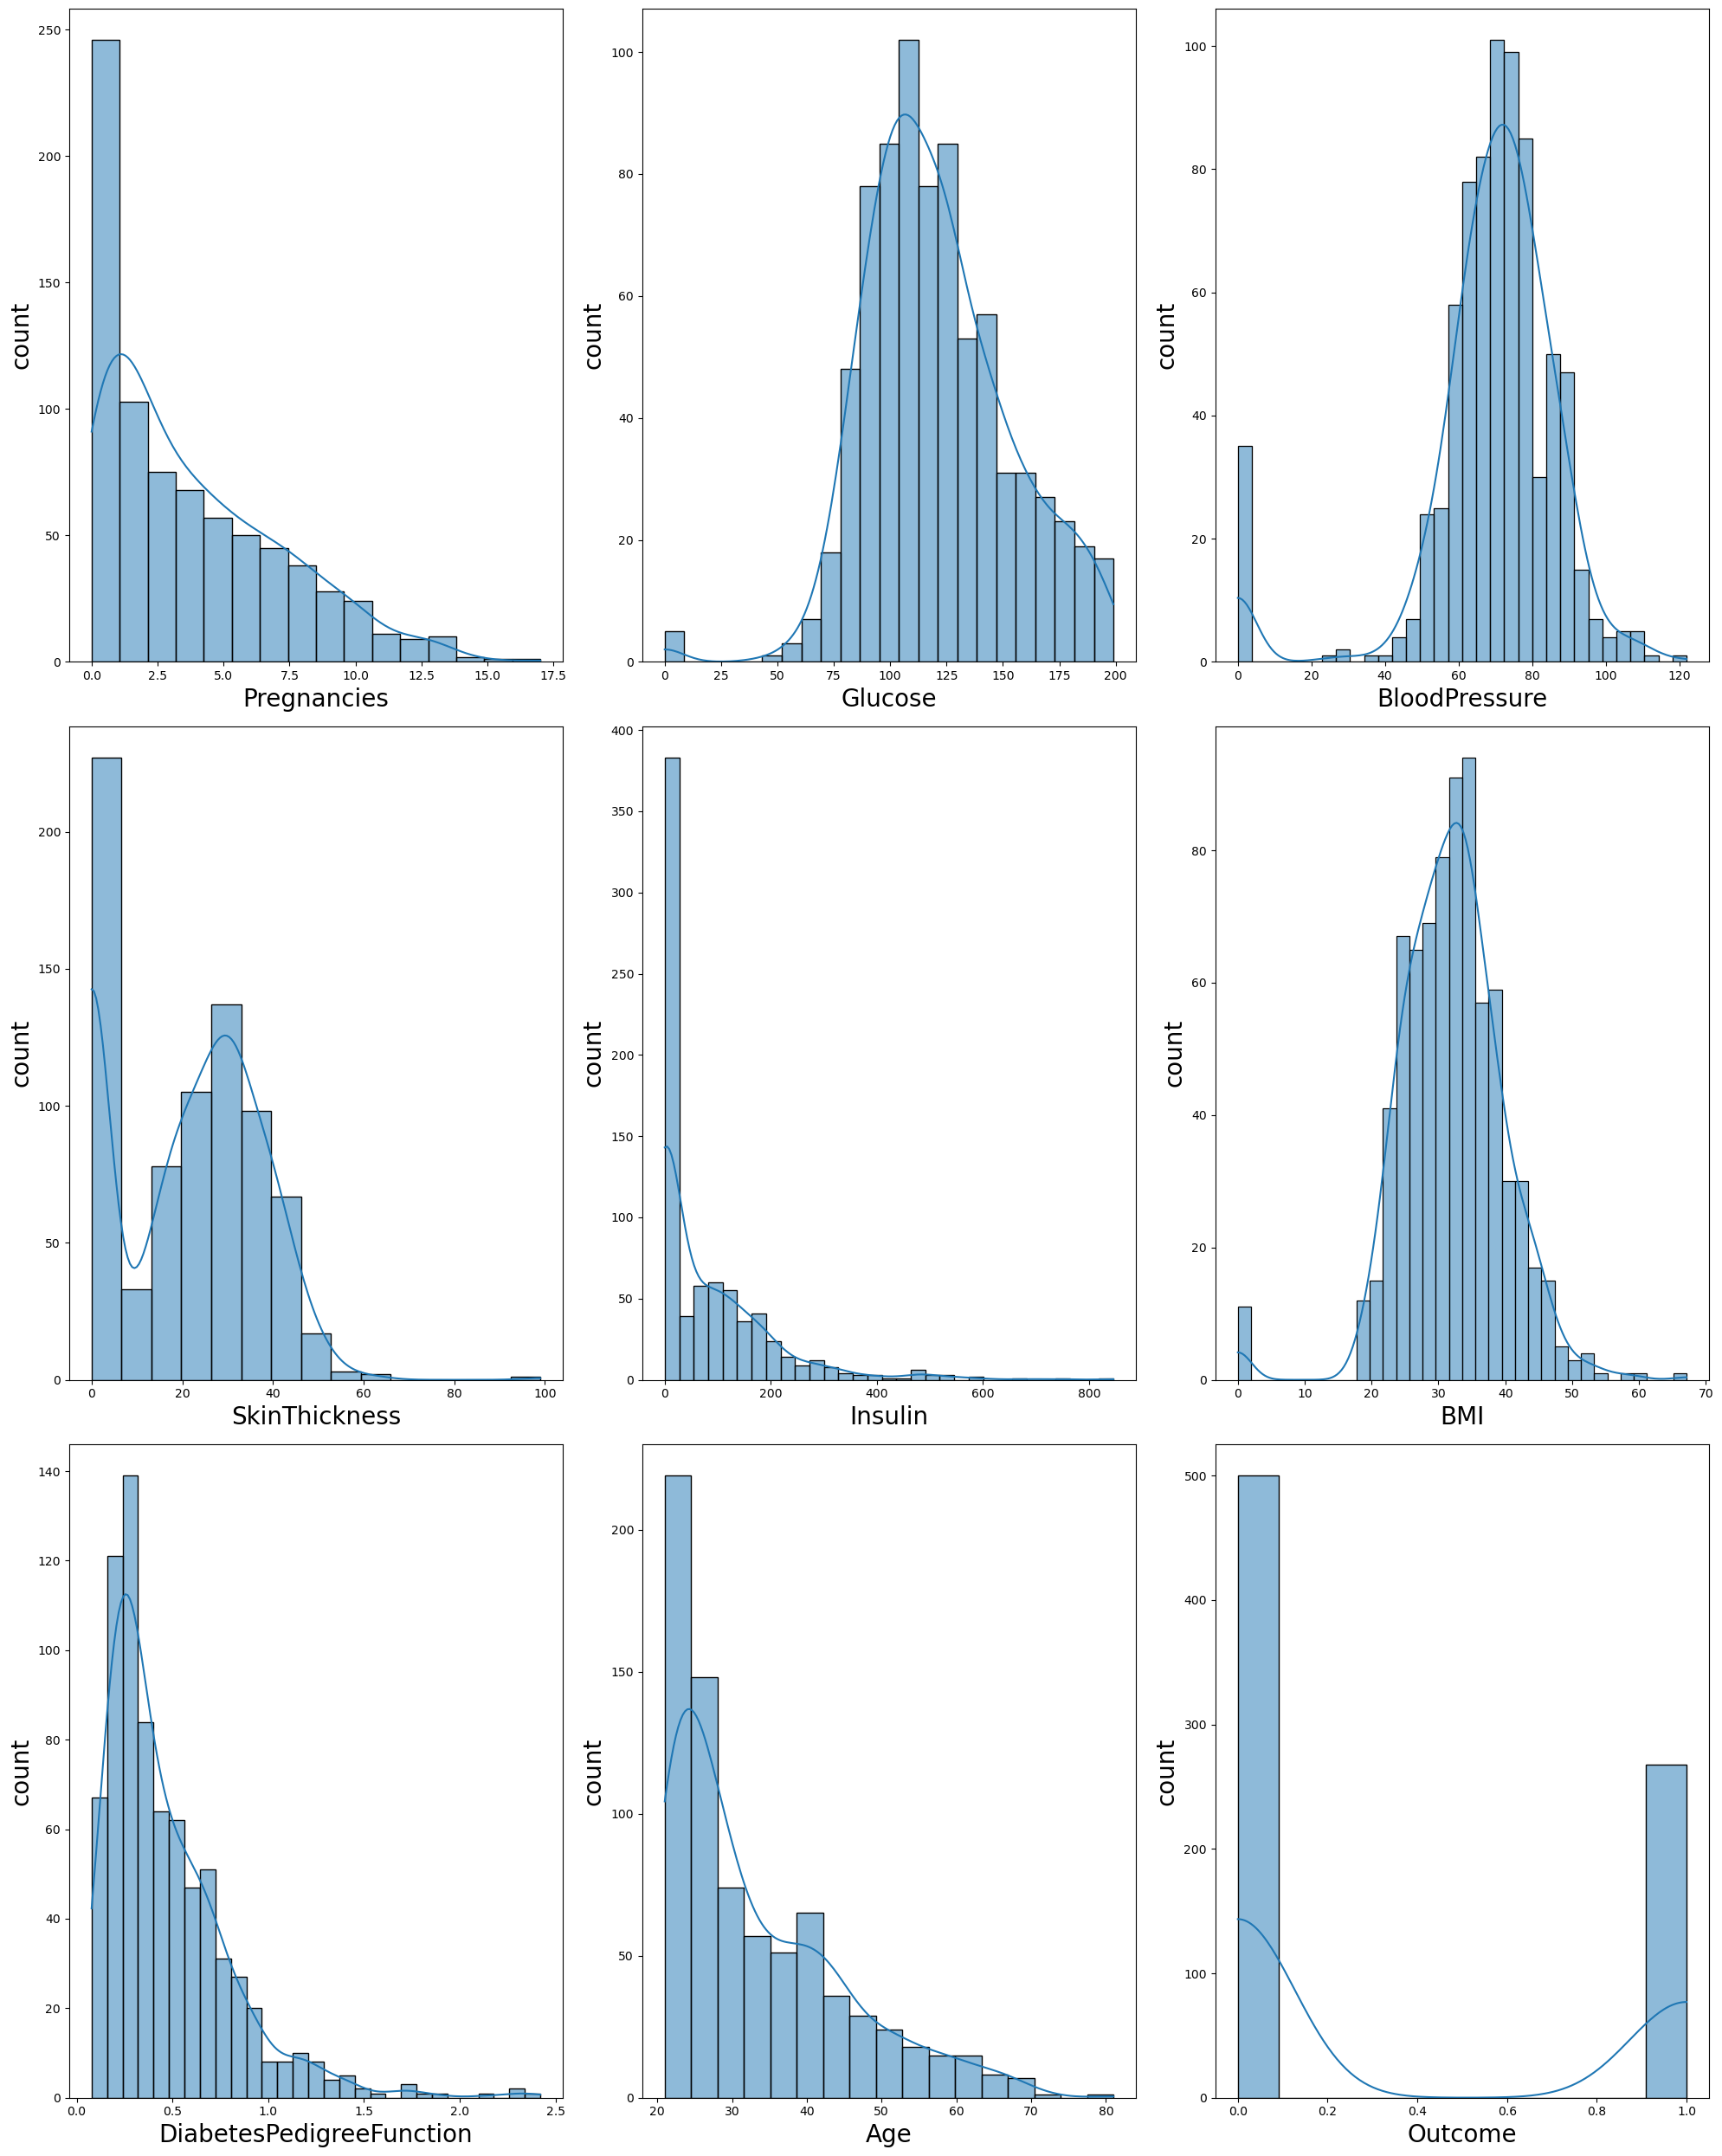

In [27]:
#check the distribution of data:
plt.figure(figsize=(20,25) ,facecolor="white")
pltnumber=1
for column in  data:
    if pltnumber <=9:
        ax=plt.subplot(3,3,pltnumber)
        sns.histplot(x=data[column],kde=True)
        plt.xlabel(column,fontsize=20)
        plt.ylabel("count",fontsize=20)
        pltnumber+=1
plt.tight_layout()



In [28]:
#insgihts:
# Glucose,BP,BMI represents normal distribution

<Axes: xlabel='Pregnancies', ylabel='count'>

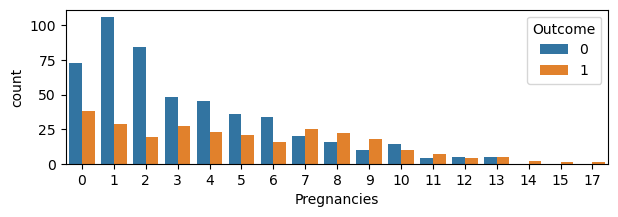

In [35]:
#Bivariant
plt.figure(figsize=(7,2))
sns.countplot(data=data ,x='Pregnancies' ,hue='Outcome')

In [37]:
#insights:
# * Max patients concievd 0 or 1 times
# * As the number of preganencies is high, the probability of being diabetic is also high.
# * As the number of preganencies is low,the probability of being diabetic is also low

<Axes: xlabel='Glucose', ylabel='Count'>

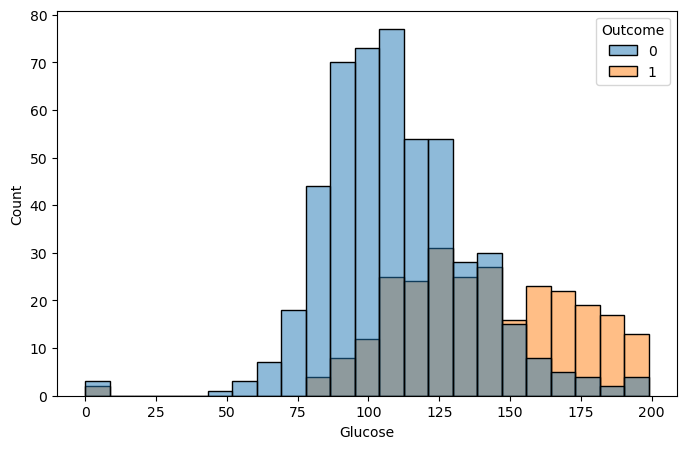

In [39]:
#Analyse the releationship between glucose and diabetic
plt.figure(figsize=(8,5))
sns.histplot(data=data,x='Glucose',hue='Outcome')

In [42]:
#insight:
# * if the glucose level is high chance of being diabetic is also high
 # * if the glucose level is less chance of being diabetic is also less

<Axes: xlabel='BloodPressure', ylabel='Count'>

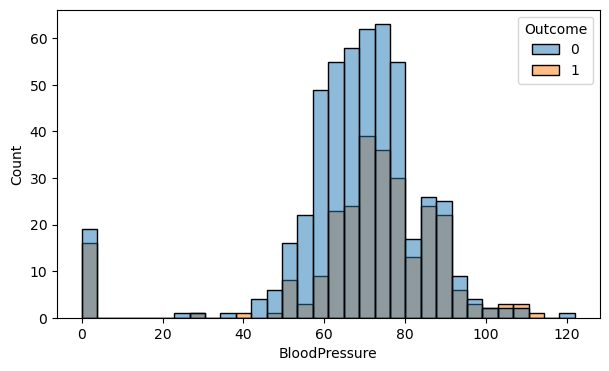

In [41]:
#Analye the relationship between BP and diabetes
plt.figure(figsize=(7,4))
sns.histplot(data=data,x='BloodPressure',hue='Outcome')

In [43]:
#insight:
# * chance of being diabetics is less if the BP is low or normal
# * chance of being diabetics is high if BP is very high


<Axes: xlabel='Insulin', ylabel='Count'>

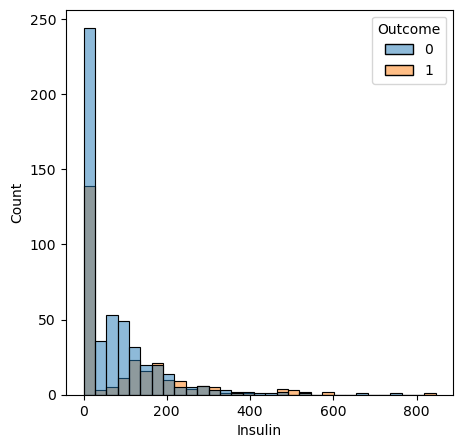

In [45]:
#Analyse the releationship between Insulin and diabetic
plt.figure(figsize=(5,5))
sns.histplot(data=data,x='Insulin',hue='Outcome')


In [46]:
#insights:
# * the chance of being diabetic is less if the insulin level is less
# *the chance of being diabetic is high if the insulin level is high